In [ ]:
# ==================== PART 1: SETUP AND DATA LOADING ====================

# Install required libraries
!pip install sentence-transformers

# Import libraries
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Sklearn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# Keras/TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# For contextual embeddings
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# ==================== PART 2: LOAD AND EXPLORE DATA ====================

# Load dataset
data = pd.read_csv(
    '/content/fake_job_postings.csv',
    engine='python',
    on_bad_lines='skip'
)

print("Dataset Shape:", data.shape)
print("\nFirst few rows:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

print("\nTarget Distribution:")
print(data['fraudulent'].value_counts())

Dataset Shape: (17880, 18)

First few rows:
   job_id                                      title            location  \
0       1                           Marketing Intern    US, NY, New York   
1       2  Customer Service - Cloud Video Production      NZ, , Auckland   
2       3    Commissioning Machinery Assistant (CMA)       US, IA, Wever   
3       4          Account Executive - Washington DC  US, DC, Washington   
4       5                        Bill Review Manager  US, FL, Fort Worth   

  department salary_range                                    company_profile  \
0  Marketing          NaN  We're Food52, and we've created a groundbreaki...   
1    Success          NaN  90 Seconds, the worlds Cloud Video Production ...   
2        NaN          NaN  Valor Services provides Workforce Solutions th...   
3      Sales          NaN  Our passion for improving quality of life thro...   
4        NaN          NaN  SpotSource Solutions LLC is a Global Human Cap...   

                  

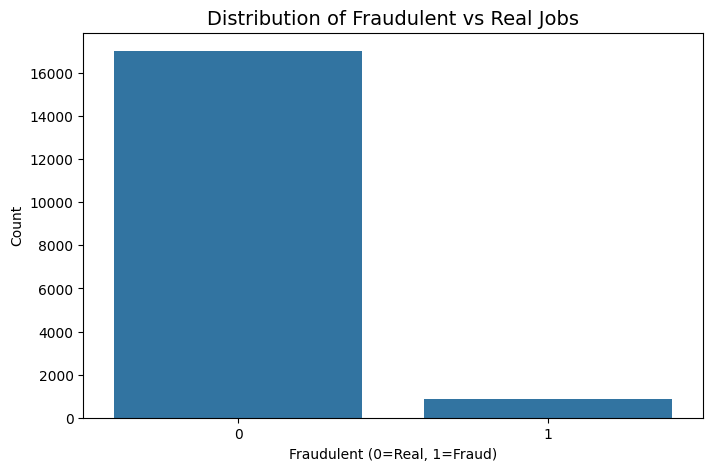


Class Distribution:
fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64


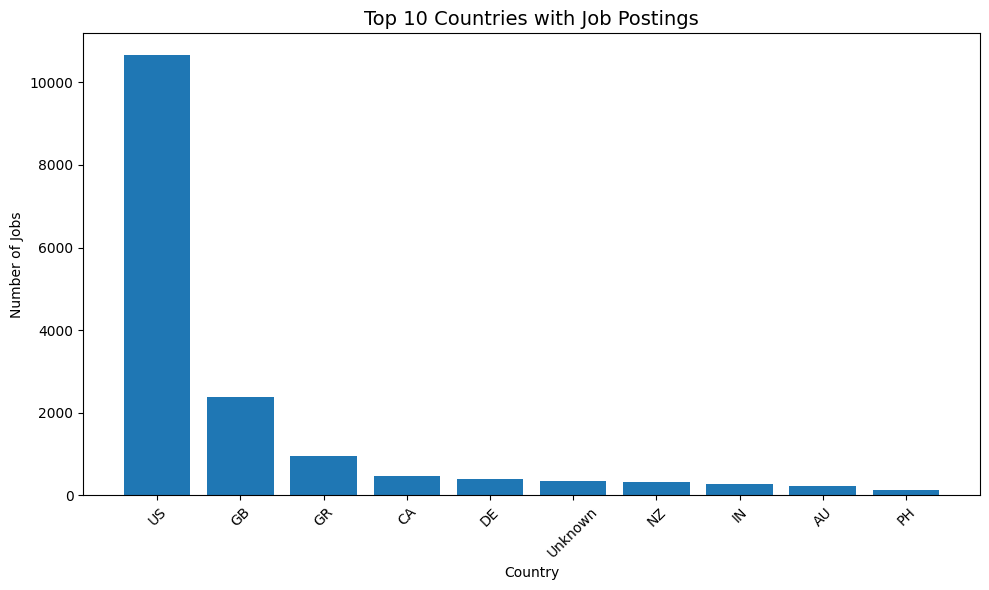

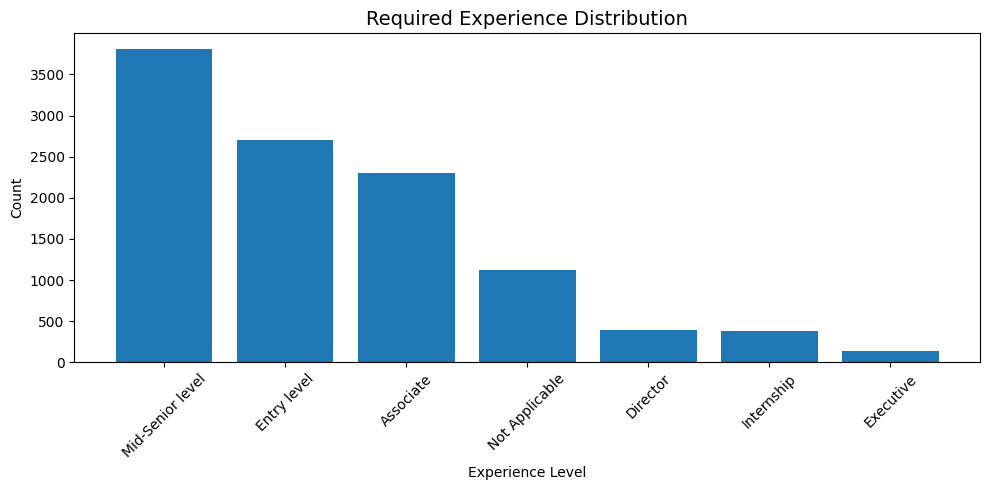

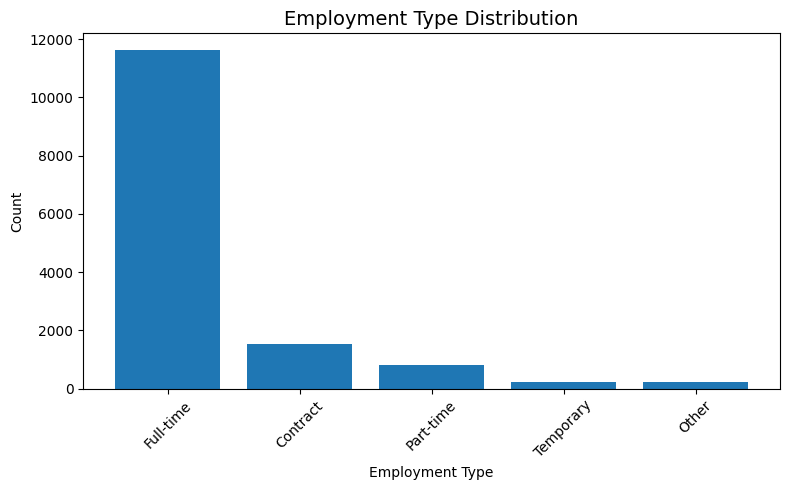


Top 10 Fraudulent Job Titles:
title
Data Entry Admin/Clerical Positions - Work From Home                    21
Cruise Staff Wanted *URGENT*                                            21
Home Based Payroll Typist/Data Entry Clerks Positions Available         21
Customer Service Representative                                         17
Administrative Assistant                                                16
Home Based Payroll Data Entry Clerk Position - Earn $100-$200 Daily     12
Account Sales Managers $80-$130,000/yr                                  10
Payroll Data Coordinator Positions - Earn $100-$200 Daily               10
Network Marketing                                                       10
Payroll Clerk                                                           10
Name: count, dtype: int64

Top 10 Real Job Titles:
title
English Teacher Abroad                                311
Customer Service Associate                            146
Graduates: English Teacher Abroad (Conve

In [ ]:

# ==================== PART 3: EXPLORATORY DATA ANALYSIS ====================

# Visualization 1: Fraudulent vs Real Jobs
plt.figure(figsize=(8, 5))
sns.countplot(x=data['fraudulent'])
plt.title('Distribution of Fraudulent vs Real Jobs', fontsize=14)
plt.xlabel('Fraudulent (0=Real, 1=Fraud)')
plt.ylabel('Count')
plt.show()

print("\nClass Distribution:")
print(data['fraudulent'].value_counts(normalize=True) * 100)

# Visualization 2: Jobs by Location
def split_location(location):
    if pd.isna(location) or location == '':
        return 'Unknown'
    return location.split(',')[0]

data['country'] = data['location'].apply(split_location)
country_counts = data['country'].value_counts()[:10]

plt.figure(figsize=(10, 6))
plt.bar(country_counts.index, country_counts.values)
plt.title('Top 10 Countries with Job Postings', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Number of Jobs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 3: Required Experience
plt.figure(figsize=(10, 5))
exp_counts = data['required_experience'].value_counts()[:10]
plt.bar(exp_counts.index, exp_counts.values)
plt.title('Required Experience Distribution', fontsize=14)
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualization 4: Employment Type
plt.figure(figsize=(8, 5))
emp_counts = data['employment_type'].value_counts()[:5]
plt.bar(emp_counts.index, emp_counts.values)
plt.title('Employment Type Distribution', fontsize=14)
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Top fraudulent job titles
print("\nTop 10 Fraudulent Job Titles:")
print(data[data['fraudulent'] == 1]['title'].value_counts()[:10])

print("\nTop 10 Real Job Titles:")
print(data[data['fraudulent'] == 0]['title'].value_counts()[:10])

In [ ]:
# ==================== PART 4: TEXT PREPROCESSING ====================

# Fill missing values
data.fillna('', inplace=True)

# Combine text features
data['combined_text'] = (
    data['title'].astype(str) + ' ' +
    data['location'].astype(str) + ' ' +
    data['company_profile'].astype(str) + ' ' +
    data['description'].astype(str) + ' ' +
    data['requirements'].astype(str) + ' ' +
    data['benefits'].astype(str)
)

# Clean text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = ' '.join(text.split())  # Remove extra whitespace
    return text

data['cleaned_text'] = data['combined_text'].apply(clean_text)

print("\nSample cleaned text:")
print(data['cleaned_text'].iloc[0][:200])


Sample cleaned text:
marketing intern us ny new york were food and weve created a groundbreaking and awardwinning cooking site we support connect and celebrate home cooks and give them everything they need in one placewe 


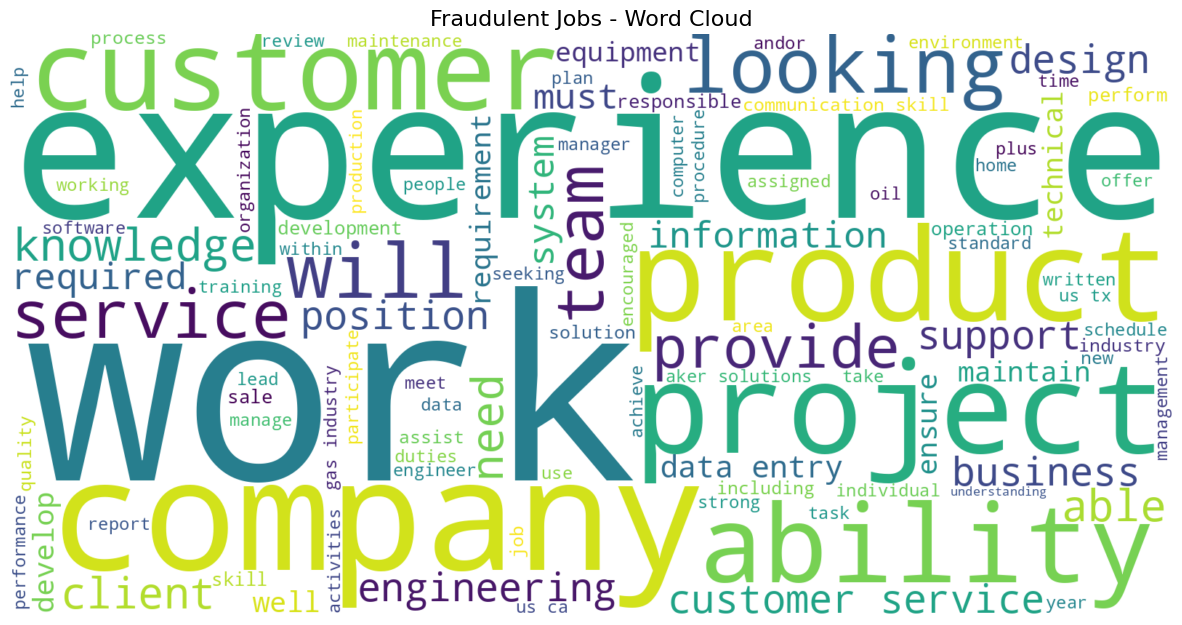

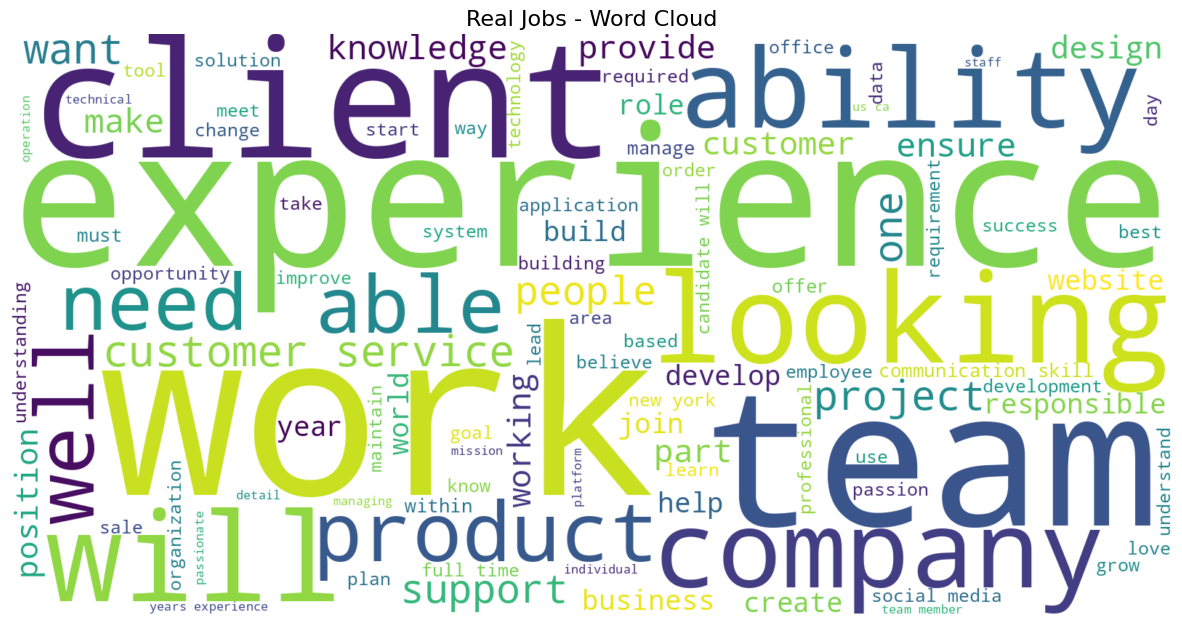

In [ ]:
# ==================== PART 5: WORD CLOUDS ====================

from wordcloud import STOPWORDS

# Fraudulent jobs word cloud
fraud_text = ' '.join(data[data['fraudulent'] == 1]['cleaned_text'])
plt.figure(figsize=(15, 8))
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=100
).generate(fraud_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Fraudulent Jobs - Word Cloud', fontsize=16)
plt.show()

# Real jobs word cloud
real_text = ' '.join(data[data['fraudulent'] == 0]['cleaned_text'])
plt.figure(figsize=(15, 8))
wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    stopwords=STOPWORDS,
    max_words=100
).generate(real_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Real Jobs - Word Cloud', fontsize=16)
plt.show()

In [ ]:
# ==================== PART 6: KEY FEATURES IDENTIFICATION ====================

# Extract key features from fraudulent jobs using TF-IDF
fraud_texts = data[data['fraudulent'] == 1]['cleaned_text']
real_texts = data[data['fraudulent'] == 0]['cleaned_text']

vectorizer = TfidfVectorizer(max_features=50, stop_words='english')
fraud_tfidf = vectorizer.fit_transform(fraud_texts)

# Get feature names and scores
feature_names = vectorizer.get_feature_names_out()
fraud_scores = fraud_tfidf.sum(axis=0).A1
fraud_features = sorted(zip(feature_names, fraud_scores), key=lambda x: x[1], reverse=True)

print("\nTop 20 Keywords in Fraudulent Jobs:")
for word, score in fraud_features[:20]:
    print(f"{word}: {score:.2f}")


Top 20 Keywords in Fraudulent Jobs:
work: 124.60
experience: 110.73
skills: 93.08
amp: 87.42
time: 75.20
customer: 73.93
service: 72.93
position: 72.23
data: 70.50
company: 66.35
business: 65.43
home: 64.56
entry: 62.76
team: 62.12
management: 61.69
looking: 59.52
ability: 58.37
sales: 57.13
office: 56.98
services: 56.72


In [ ]:
# ==================== PART 7: FEATURE ENGINEERING ====================

# Create meta-features
data['text_length'] = data['combined_text'].apply(len)
data['word_count'] = data['combined_text'].apply(lambda x: len(x.split()))
data['has_company_logo'] = data['has_company_logo'].fillna(0).astype(int)
data['has_questions'] = data['has_questions'].fillna(0).astype(int)
data['telecommuting'] = data['telecommuting'].fillna(0).astype(int)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
text_features = tfidf.fit_transform(data['cleaned_text']).toarray()

# Combine text features and meta-features
meta_features = data[['text_length', 'word_count', 'has_company_logo',
                       'has_questions', 'telecommuting']].values

X = np.hstack([text_features, meta_features])
y = data['fraudulent'].values

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Matrix Shape: (17880, 505)
Target Shape: (17880,)


In [ ]:
# ==================== PART 8: TRAIN-TEST SPLIT ====================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())


Train set size: (14304, 505)
Test set size: (3576, 505)

Train class distribution:
0    13611
1      693
Name: count, dtype: int64


In [ ]:
# ==================== PART 9: BUILD ANN MODEL ====================

# Build the ANN
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("\nModel Architecture:")
model.summary()


Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       129,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 174,593 (682.00 KB)

 Trainable params: 173,697 (678.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# ==================== PART 10: TRAIN THE MODEL ====================

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8351 - loss: 0.4086 - precision: 0.0622 - recall: 0.1500 - val_accuracy: 0.9535 - val_loss: 0.1886 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9472 - loss: 0.2215 - precision: 0.1151 - recall: 0.0083 - val_accuracy: 0.9535 - val_loss: 0.1870 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9538 - loss: 0.1954 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.9535 - val_loss: 0.1879 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9526 - loss: 0.2009 - precision: 0.0369 - recall: 2.8472e-04 - val_accuracy: 0.9535 - val_loss: 0.1862 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/50
358/358 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9498 - loss: 0.2019 - precision: 0.0000e+00 - 

112/112 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

MODEL PERFORMANCE METRICS
Accuracy:  0.9516
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.6965

Detailed Classification Report:
              precision    recall  f1-score   support

        Real       0.95      1.00      0.98      3403
  Fraudulent       0.00      0.00      0.00       173

    accuracy                           0.95      3576
   macro avg       0.48      0.50      0.49      3576
weighted avg       0.91      0.95      0.93      3576



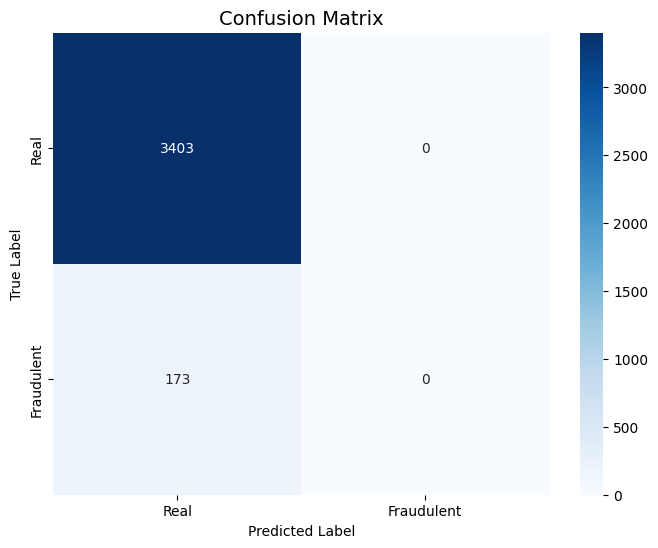

In [ ]:
# ==================== PART 11: EVALUATE THE MODEL ====================

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("="*50)

# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Real', 'Fraudulent']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fraudulent'],
            yticklabels=['Real', 'Fraudulent'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

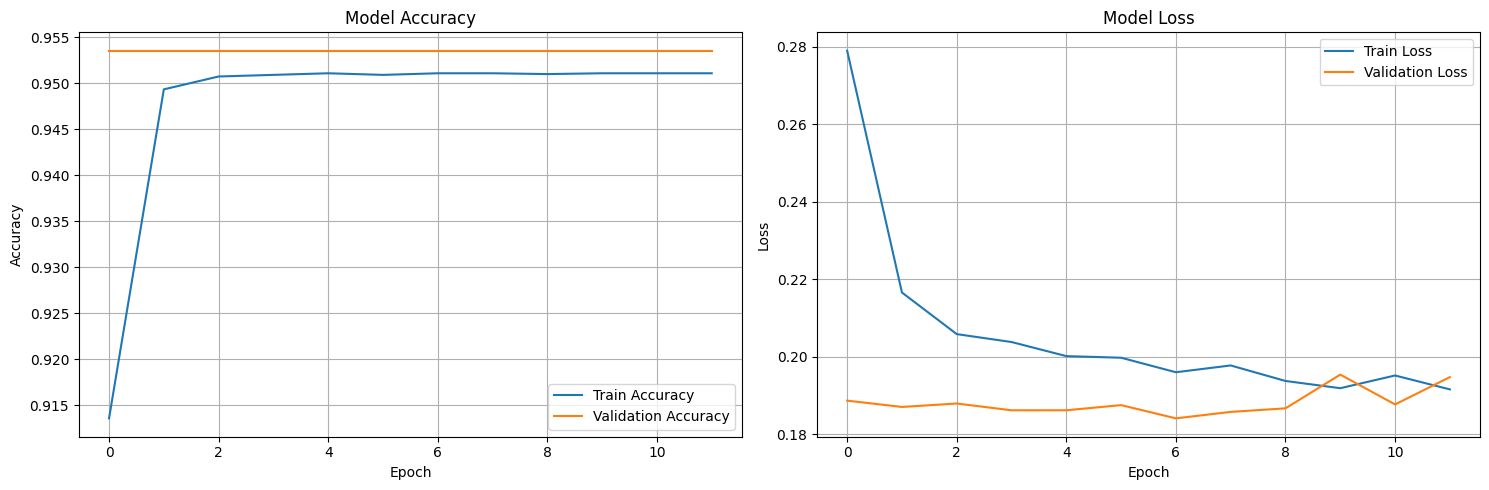

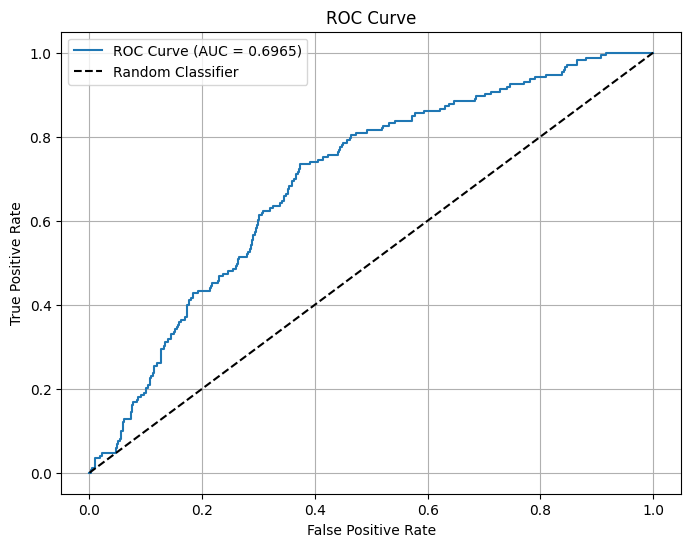

In [ ]:
# ==================== PART 12: TRAINING HISTORY VISUALIZATION ====================

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ==================== PART 13: CONTEXTUAL EMBEDDINGS ====================

print("\n" + "="*50)
print("CONTEXTUAL EMBEDDINGS - SIMILAR JOB DETECTION")
print("="*50)

# Load pre-trained sentence transformer
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Get a sample fraudulent job for similarity search
fraud_jobs = data[data['fraudulent'] == 1]['cleaned_text'].head(100).tolist()
all_jobs = data['cleaned_text'].head(500).tolist()

print("\nGenerating embeddings...")
fraud_embeddings = embedding_model.encode(fraud_jobs)
all_embeddings = embedding_model.encode(all_jobs)

# Find most similar jobs to a fraudulent job
sample_fraud_idx = 0
sample_fraud_text = fraud_jobs[sample_fraud_idx]

print(f"\nSample Fraudulent Job Description:")
print(sample_fraud_text[:300] + "...")

# Calculate similarity
similarities = cosine_similarity([fraud_embeddings[sample_fraud_idx]], all_embeddings)[0]
top_5_indices = similarities.argsort()[-6:-1][::-1]  # Top 5 excluding itself

print("\n\nTop 5 Most Similar Job Descriptions:")
for i, idx in enumerate(top_5_indices, 1):
    print(f"\n{i}. Similarity Score: {similarities[idx]:.4f}")
    print(f"   Text: {all_jobs[idx][:200]}...")


CONTEXTUAL EMBEDDINGS - SIMILAR JOB DETECTION


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Generating embeddings...

Sample Fraudulent Job Description:
ice technician us stocton ca staffing amp recruiting done right for the oil amp energy industryrepresented candidates are automatically granted the following perks expert negotiations on your behalf maximizing your compensation package and implimenting ongoing increases significant signing bonus by ...


Top 5 Most Similar Job Descriptions:

1. Similarity Score: 0.9705
   Text: ice technician mt poso us ca bakersfield ca mt poso staffing amp recruiting done right for the oil amp energy industryrepresented candidates are automatically granted the following perks expert negoti...

2. Similarity Score: 0.5832
   Text: technician instrument controls us edison international and refined resources have partnered up in an effort to streamline the hiring process and provide a more efficient and effective recruitng model ...

3. Similarity Score: 0.5608
   Text: interviewing now for sales rep positions with management training us tx c

In [ ]:
# ==================== PART 14: SUMMARY ====================

print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)
print(f"✓ Dataset analyzed: {len(data)} job postings")
print(f"✓ Fraudulent jobs: {data['fraudulent'].sum()} ({data['fraudulent'].sum()/len(data)*100:.2f}%)")
print(f"✓ Real jobs: {(data['fraudulent']==0).sum()} ({(data['fraudulent']==0).sum()/len(data)*100:.2f}%)")
print(f"\n✓ ANN Model Performance:")
print(f"  - Accuracy: {accuracy:.4f}")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall: {recall:.4f}")
print(f"  - F1-Score: {f1:.4f}")
print(f"  - ROC-AUC: {roc_auc:.4f}")
print("\n✓ Key fraudulent job features identified")
print("✓ Contextual embeddings model for similarity detection implemented")
print("✓ Comprehensive EDA completed")
print("="*70)


PROJECT SUMMARY
✓ Dataset analyzed: 17880 job postings
✓ Fraudulent jobs: 866 (4.84%)
✓ Real jobs: 17014 (95.16%)

✓ ANN Model Performance:
  - Accuracy: 0.9516
  - Precision: 0.0000
  - Recall: 0.0000
  - F1-Score: 0.0000
  - ROC-AUC: 0.6965

✓ Key fraudulent job features identified
✓ Contextual embeddings model for similarity detection implemented
✓ Comprehensive EDA completed
